# Week 8 - Notebook 2: Regression Algorithms

**Course**: Introduction to Scientific Programming (CNC-UC)  
**Topic**: Machine Learning Regression with Real-World Data

---

## Learning Objectives

By the end of this notebook, you will:
- Understand regression for continuous outcome prediction
- Implement linear regression, regularization (Ridge/Lasso), and tree-based regression
- Evaluate regression models using appropriate metrics
- Handle overfitting through regularization
- Apply regression to neuroscience-relevant problems

## 1. Setup and Data Loading

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)

# Set random seed
np.random.seed(42)

# Configure plotting
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Dataset: Diabetes Progression

The **Diabetes dataset** contains measurements from diabetes patients and a quantitative measure of disease progression one year after baseline.

**Context**: Predict disease progression from baseline clinical measurements.

**Relevance to Neuroscience**: Similar to predicting cognitive decline from baseline neurological assessments, or predicting treatment response from neural biomarkers.

**Features**: Age, sex, BMI, blood pressure, and 6 blood serum measurements.

In [2]:
# Load diabetes dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target  # Quantitative measure of disease progression
feature_names = diabetes.feature_names

# Create DataFrame
df_diabetes = pd.DataFrame(X, columns=feature_names)
df_diabetes['target'] = y

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"\nTarget statistics:")
print(f"Mean: {y.mean():.2f}")
print(f"Std:  {y.std():.2f}")
print(f"Min:  {y.min():.2f}")
print(f"Max:  {y.max():.2f}")

# Display first few rows
df_diabetes.head()

Dataset shape: (442, 10)
Number of samples: 442
Number of features: 10

Target statistics:
Mean: 152.13
Std:  77.01
Min:  25.00
Max:  346.00


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


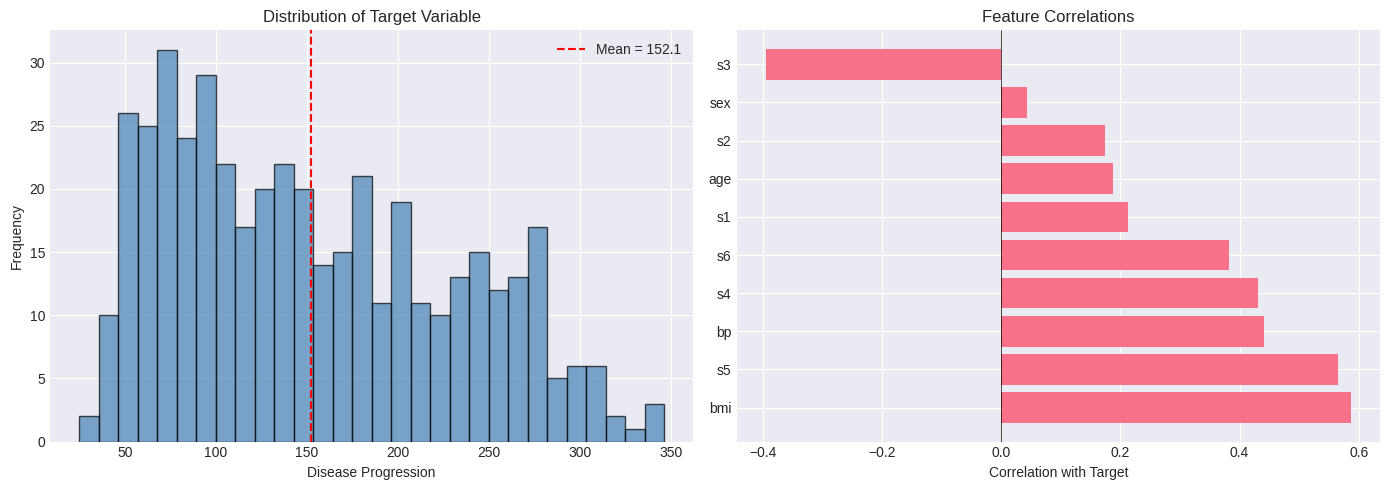


Top 3 correlated features:
bmi    0.586450
s5     0.565883
bp     0.441482
Name: target, dtype: float64


In [3]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(y, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Disease Progression')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Target Variable')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean = {y.mean():.1f}')
axes[0].legend()

# Feature correlations with target
correlations = df_diabetes.corr()['target'].drop('target').sort_values(ascending=False)
axes[1].barh(range(len(correlations)), correlations.values)
axes[1].set_yticks(range(len(correlations)))
axes[1].set_yticklabels(correlations.index)
axes[1].set_xlabel('Correlation with Target')
axes[1].set_title('Feature Correlations')
axes[1].axvline(0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nTop 3 correlated features:")
print(correlations.head(3))

### 2.1 Data Preparation

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTarget statistics (train):")
print(f"Mean: {y_train.mean():.2f}")
print(f"Std:  {y_train.std():.2f}")

Training set size: 353
Test set size: 89

Target statistics (train):
Mean: 153.74
Std:  77.95


## 3. Linear Regression

**Linear Regression** finds the best-fitting straight line through the data.

**Formula**: $\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$

**Key Properties**:
- Simple and interpretable
- Fast to train
- Assumes linear relationship
- Can overfit with many features

Linear Regression Results:

Training Set:
  R² Score: 0.5279
  RMSE:     53.56

Test Set:
  R² Score: 0.4526
  RMSE:     53.85
  MAE:      42.79


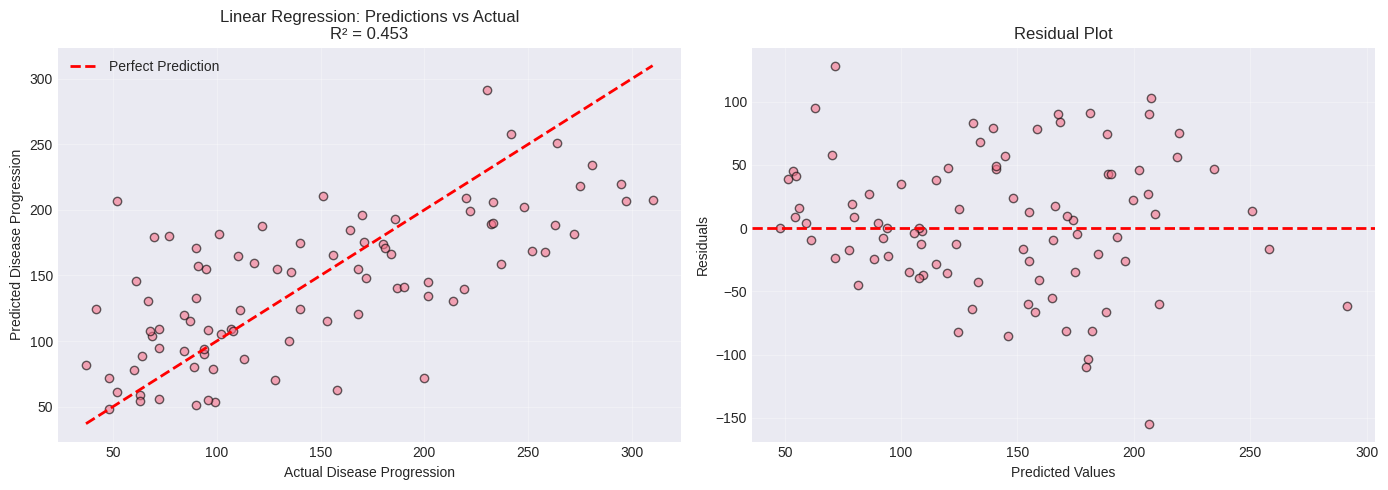


Interpretation:
- Points near the red line = good predictions
- Residuals should be randomly scattered around zero


In [5]:
# Train linear regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train_lr = lr_model.predict(X_train_scaled)
y_pred_test_lr = lr_model.predict(X_test_scaled)

# Evaluate
r2_train_lr = r2_score(y_train, y_pred_train_lr)
r2_test_lr = r2_score(y_test, y_pred_test_lr)
rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))
mae_test_lr = mean_absolute_error(y_test, y_pred_test_lr)

print("Linear Regression Results:")
print(f"\nTraining Set:")
print(f"  R² Score: {r2_train_lr:.4f}")
print(f"  RMSE:     {rmse_train_lr:.2f}")
print(f"\nTest Set:")
print(f"  R² Score: {r2_test_lr:.4f}")
print(f"  RMSE:     {rmse_test_lr:.2f}")
print(f"  MAE:      {mae_test_lr:.2f}")

# Visualize predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_test_lr, alpha=0.6, edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Disease Progression')
axes[0].set_ylabel('Predicted Disease Progression')
axes[0].set_title(f'Linear Regression: Predictions vs Actual\nR² = {r2_test_lr:.3f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_test - y_pred_test_lr
axes[1].scatter(y_pred_test_lr, residuals, alpha=0.6, edgecolors='k')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Points near the red line = good predictions")
print("- Residuals should be randomly scattered around zero")

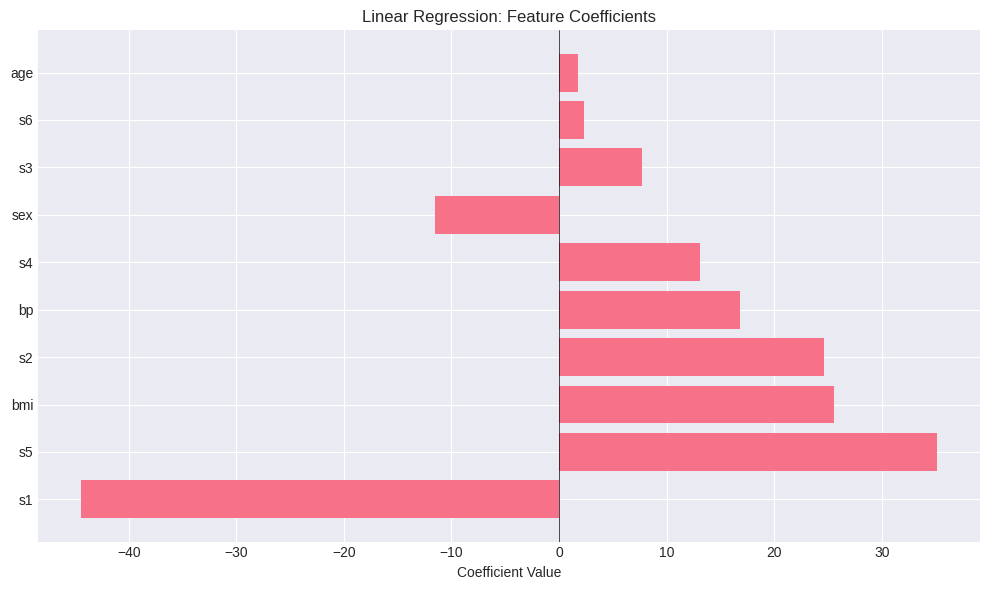


Coefficient Interpretation:
- Positive: Feature increases disease progression
- Negative: Feature decreases disease progression
- Magnitude: Strength of relationship


In [6]:
# Examine coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Linear Regression: Feature Coefficients')
plt.axvline(0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nCoefficient Interpretation:")
print("- Positive: Feature increases disease progression")
print("- Negative: Feature decreases disease progression")
print("- Magnitude: Strength of relationship")

## 4. Regularization: Ridge, Lasso, and ElasticNet

**Regularization** adds a penalty term to prevent overfitting.

### Ridge Regression (L2 Regularization)
- Penalty: $\lambda \sum_{i=1}^{n} \beta_i^2$
- Shrinks coefficients toward zero
- Keeps all features

### Lasso Regression (L1 Regularization)
- Penalty: $\lambda \sum_{i=1}^{n} |\beta_i|$
- Can set coefficients exactly to zero
- Performs feature selection

### ElasticNet
- Combines L1 and L2 penalties
- Balance between Ridge and Lasso

Regularization Comparison:

            Model  R² Score      RMSE       MAE
Linear Regression  0.452603 53.853446 42.794095
            Ridge  0.454147 53.777454 42.811999
            Lasso  0.460661 53.455580 42.839517
       ElasticNet  0.462190 53.379753 43.199065


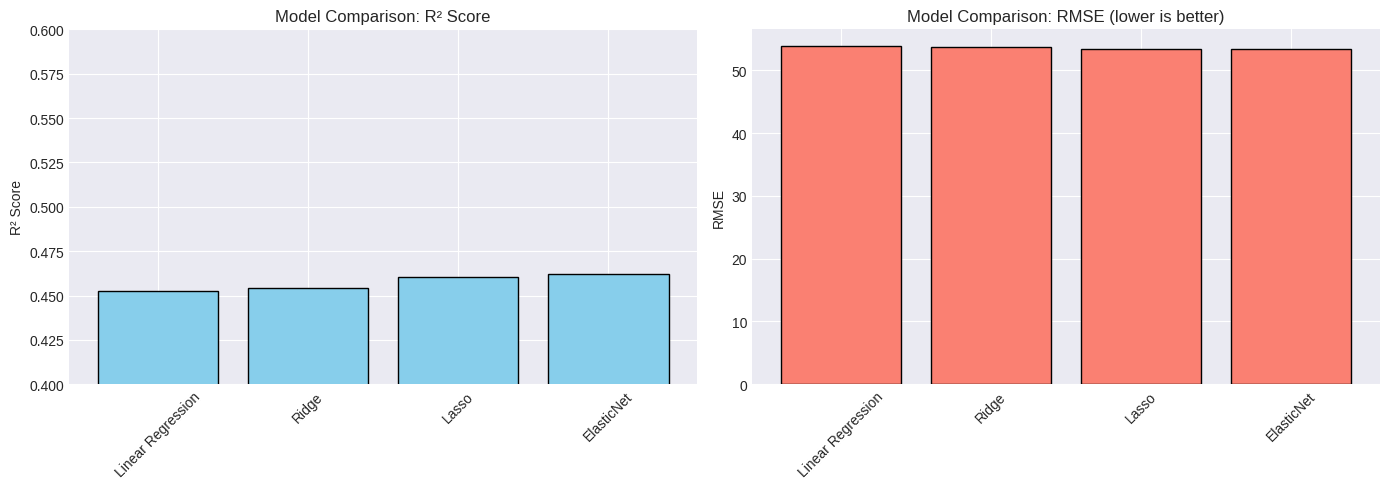

In [7]:
# Train regularized models
ridge_model = Ridge(alpha=1.0, random_state=42)
lasso_model = Lasso(alpha=0.5, random_state=42)
elastic_model = ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=42)

# Fit models
ridge_model.fit(X_train_scaled, y_train)
lasso_model.fit(X_train_scaled, y_train)
elastic_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_ridge = ridge_model.predict(X_test_scaled)
y_pred_lasso = lasso_model.predict(X_test_scaled)
y_pred_elastic = elastic_model.predict(X_test_scaled)

# Evaluate
results_reg = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet'],
    'R² Score': [
        r2_score(y_test, y_pred_test_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_elastic)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_test_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_elastic))
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_test_lr),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_elastic)
    ]
})

print("Regularization Comparison:\n")
print(results_reg.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
axes[0].bar(results_reg['Model'], results_reg['R² Score'], color='skyblue', edgecolor='black')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Comparison: R² Score')
axes[0].set_ylim(0.4, 0.6)
axes[0].tick_params(axis='x', rotation=45)

# RMSE comparison
axes[1].bar(results_reg['Model'], results_reg['RMSE'], color='salmon', edgecolor='black')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

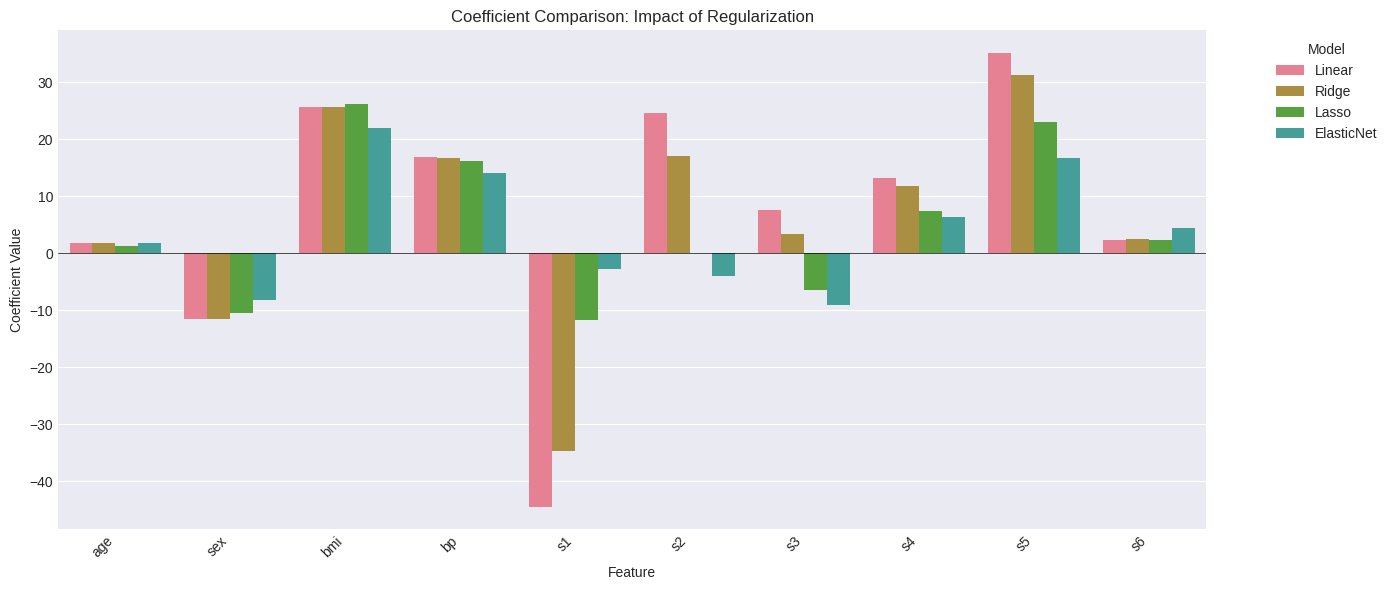


Feature Selection (coefficients set to zero):
Linear Regression: 0 features
Ridge: 0 features
Lasso: 1 features (performs feature selection!)
ElasticNet: 0 features


In [8]:
# Compare coefficients across regularization methods
coef_comparison = pd.DataFrame({
    'Feature': feature_names,
    'Linear': lr_model.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_,
    'ElasticNet': elastic_model.coef_
})

# Plot coefficient comparison
coef_comparison_melted = coef_comparison.melt(id_vars='Feature', 
                                               var_name='Model', 
                                               value_name='Coefficient')

plt.figure(figsize=(14, 6))
sns.barplot(data=coef_comparison_melted, x='Feature', y='Coefficient', hue='Model')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linestyle='-', linewidth=0.5)
plt.title('Coefficient Comparison: Impact of Regularization')
plt.ylabel('Coefficient Value')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Count zero coefficients (feature selection)
print("\nFeature Selection (coefficients set to zero):")
print(f"Linear Regression: {np.sum(lr_model.coef_ == 0)} features")
print(f"Ridge: {np.sum(ridge_model.coef_ == 0)} features")
print(f"Lasso: {np.sum(lasso_model.coef_ == 0)} features (performs feature selection!)")
print(f"ElasticNet: {np.sum(elastic_model.coef_ == 0)} features")

## 5. Tree-Based Regression

**Decision Trees** and **Random Forests** can also be used for regression.

**Advantages**:
- Handle non-linear relationships
- No feature scaling required
- Provide feature importance
- Robust to outliers

In [9]:
# Train tree-based models
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

# Fit models (no scaling needed)
tree_reg.fit(X_train, y_train)
rf_reg.fit(X_train, y_train)

# Predictions
y_pred_tree = tree_reg.predict(X_test)
y_pred_rf = rf_reg.predict(X_test)

# Evaluate
r2_tree = r2_score(y_test, y_pred_tree)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Tree-Based Regression Results:\n")
print(f"Decision Tree:")
print(f"  R² Score: {r2_tree:.4f}")
print(f"  RMSE:     {rmse_tree:.2f}")
print(f"\nRandom Forest:")
print(f"  R² Score: {r2_rf:.4f}")
print(f"  RMSE:     {rmse_rf:.2f}")

Tree-Based Regression Results:

Decision Tree:
  R² Score: 0.3345
  RMSE:     59.38

Random Forest:
  R² Score: 0.4561
  RMSE:     53.68


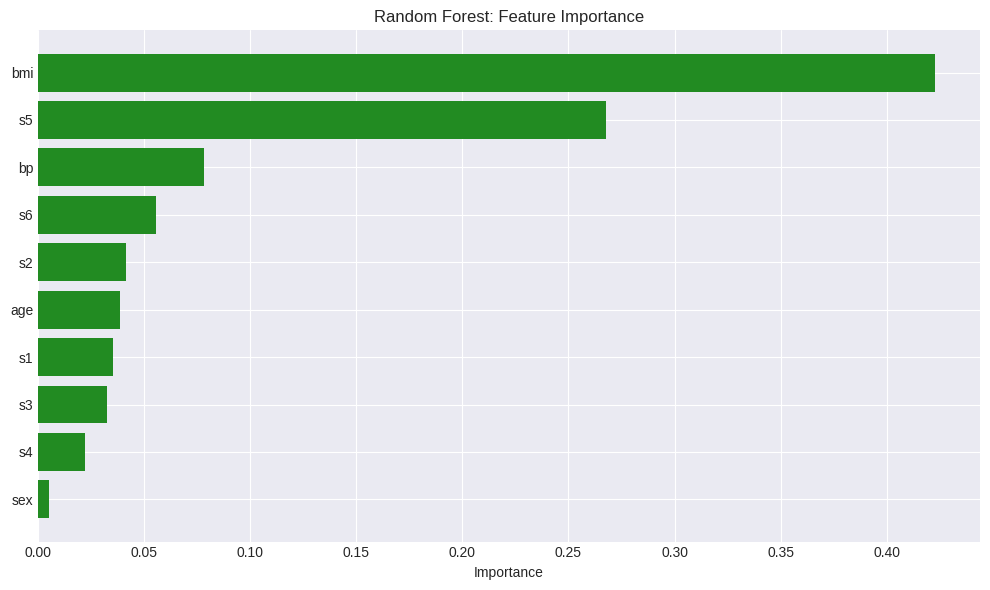


Top 3 most important features:
Feature  Importance
    bmi    0.422847
     s5    0.267851
     bp    0.078161


In [10]:
# Feature importance from Random Forest
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='forestgreen')
plt.xlabel('Importance')
plt.title('Random Forest: Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
print(importance_df.head(3).to_string(index=False))

## 6. Large-Scale Regression: California Housing

Let's test our models on a larger dataset with real-world economic data.

**Dataset**: California Housing (20,640 samples)
**Task**: Predict median house value from census data

**Relevance to Neuroscience**: Demonstrates scalability for large neuroimaging datasets.

In [11]:
# Load California housing dataset
housing = fetch_california_housing()
X_house = housing.data
y_house = housing.target  # Median house value (in $100,000s)

print(f"Dataset shape: {X_house.shape}")
print(f"Features: {housing.feature_names}")
print(f"\nTarget statistics (Median House Value in $100k):")
print(f"Mean: ${y_house.mean():.2f}00,000")
print(f"Min:  ${y_house.min():.2f}00,000")
print(f"Max:  ${y_house.max():.2f}00,000")

# Quick model comparison on large dataset
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)

scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled = scaler_h.transform(X_test_h)

Dataset shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target statistics (Median House Value in $100k):
Mean: $2.0700,000
Min:  $0.1500,000
Max:  $5.0000,000


In [12]:
# Compare models on large dataset
models_large = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
}

results_large = []
for name, model in models_large.items():
    # Use scaled data for linear models, unscaled for RF
    if 'Forest' in name:
        model.fit(X_train_h, y_train_h)
        y_pred = model.predict(X_test_h)
    else:
        model.fit(X_train_h_scaled, y_train_h)
        y_pred = model.predict(X_test_h_scaled)
    
    r2 = r2_score(y_test_h, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_h, y_pred))
    mae = mean_absolute_error(y_test_h, y_pred)
    
    results_large.append({
        'Model': name,
        'R² Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })

results_large_df = pd.DataFrame(results_large)
print("Results on Large Dataset (California Housing):\n")
print(results_large_df.to_string(index=False))

print("\nInterpretation:")
print(f"- RMSE of {results_large_df.iloc[0]['RMSE']:.2f} means average error of ${results_large_df.iloc[0]['RMSE']*100000:.0f}")
print(f"- R² of {results_large_df.iloc[0]['R² Score']:.3f} means model explains {results_large_df.iloc[0]['R² Score']*100:.1f}% of variance")

Results on Large Dataset (California Housing):

            Model  R² Score     RMSE      MAE
Linear Regression  0.575788 0.745581 0.533200
            Ridge  0.575816 0.745557 0.533193
    Random Forest  0.773208 0.545151 0.367484

Interpretation:
- RMSE of 0.75 means average error of $74558
- R² of 0.576 means model explains 57.6% of variance


## 7. Understanding Metrics

### R² (Coefficient of Determination)
- Range: $-\infty$ to 1
- R² = 1: Perfect predictions
- R² = 0: Model is no better than predicting the mean
- R² < 0: Model is worse than predicting the mean

### RMSE (Root Mean Squared Error)
- In same units as target variable
- Penalizes large errors more than MAE
- Lower is better

### MAE (Mean Absolute Error)
- Average absolute difference between predictions and actual values
- More robust to outliers than RMSE
- Lower is better

In [13]:
# Visualize metric relationships
# Create predictions with varying quality
y_true = np.array([1, 2, 3, 4, 5])
y_pred_perfect = np.array([1, 2, 3, 4, 5])
y_pred_good = np.array([1.2, 2.1, 2.9, 4.1, 4.8])
y_pred_poor = np.array([2, 1, 4, 3, 5])

predictions = [
    ('Perfect', y_pred_perfect),
    ('Good', y_pred_good),
    ('Poor', y_pred_poor)
]

print("Metric Comparison for Different Prediction Qualities:\n")
for name, y_pred in predictions:
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name:8s}: R² = {r2:6.3f}, RMSE = {rmse:5.3f}, MAE = {mae:5.3f}")

Metric Comparison for Different Prediction Qualities:

Perfect : R² =  1.000, RMSE = 0.000, MAE = 0.000
Good    : R² =  0.989, RMSE = 0.148, MAE = 0.140
Poor    : R² =  0.600, RMSE = 0.894, MAE = 0.800


## 8. Complete Model Comparison


FINAL MODEL COMPARISON - Diabetes Dataset
            Model       R²      RMSE       MAE
       ElasticNet 0.462190 53.379753 43.199065
    Lasso (α=0.5) 0.460661 53.455580 42.839517
    Random Forest 0.456116 53.680342 43.561625
    Ridge (α=1.0) 0.454147 53.777454 42.811999
Linear Regression 0.452603 53.853446 42.794095
    Decision Tree 0.334482 59.380262 45.936955


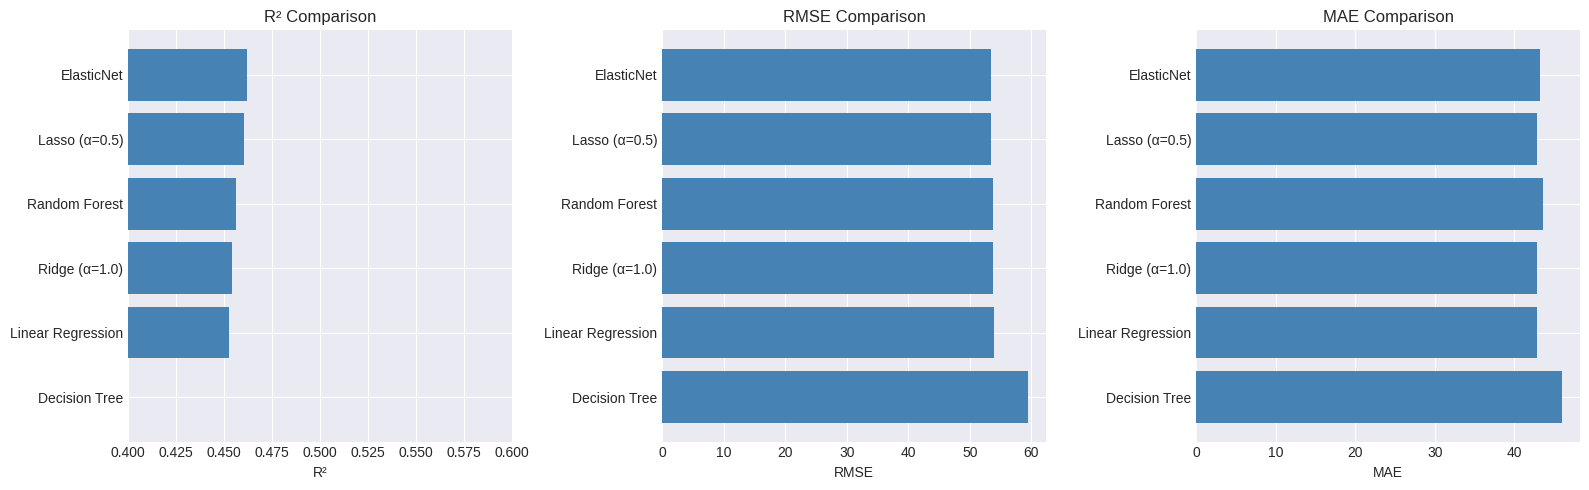

In [14]:
# Final comprehensive comparison on diabetes dataset
all_models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Lasso (α=0.5)': Lasso(alpha=0.5),
    'ElasticNet': ElasticNet(alpha=0.5, l1_ratio=0.5),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
}

final_results = []
for name, model in all_models.items():
    # Use appropriate data (scaled vs unscaled)
    if 'Tree' in name or 'Forest' in name:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    
    final_results.append({
        'Model': name,
        'R²': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred)
    })

final_df = pd.DataFrame(final_results).sort_values('R²', ascending=False)
print("\n" + "="*60)
print("FINAL MODEL COMPARISON - Diabetes Dataset")
print("="*60)
print(final_df.to_string(index=False))
print("="*60)

# Visualize final comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, metric in enumerate(['R²', 'RMSE', 'MAE']):
    axes[idx].barh(final_df['Model'], final_df[metric], color='steelblue')
    axes[idx].set_xlabel(metric)
    axes[idx].set_title(f'{metric} Comparison')
    if metric == 'R²':
        axes[idx].set_xlim(0.4, 0.6)
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Key Takeaways

### When to Use Each Algorithm:

**Linear Regression**:
- Fast baseline model
- When relationships are truly linear
- When interpretability is critical

**Ridge Regression**:
- Many correlated features
- Want to keep all features
- Need regularization but not feature selection

**Lasso Regression**:
- Want automatic feature selection
- Believe many features are irrelevant
- Need sparse solutions

**Tree-Based Methods**:
- Non-linear relationships
- Feature interactions important
- Robustness to outliers needed
- Feature scaling is inconvenient

### Regression Best Practices:
1. **Always check R²**: Explains variance in predictions
2. **Use RMSE for comparisons**: Same units as target
3. **Plot residuals**: Check for patterns (should be random)
4. **Try regularization**: Often improves generalization
5. **Consider non-linear models**: If linear models underperform

## 10. Practice Exercises

1. **Hyperparameter Tuning**: Try different alpha values for Ridge (0.01, 0.1, 1.0, 10, 100). How does performance change?

2. **Feature Engineering**: Create interaction features (e.g., BMI × blood pressure). Does this improve predictions?

3. **Cross-Validation**: Use 5-fold CV to get more reliable performance estimates for all models.

4. **Polynomial Features**: Add polynomial features (degree=2) to linear regression. What happens to R² and RMSE?

5. **Your Own Data**: Apply these techniques to continuous outcome variables in your own research!